# RAGMAR - online-phase Analysis

In [24]:
from pathlib import Path
import json, re, string
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

MPL = tuple(int(x) for x in matplotlib.__version__.split(".")[:2])
# np.trapz was renamed np.trapezoid in numpy 2.0.
trapz = getattr(np, "trapezoid", None) or np.trapz

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 80)
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (10, 4),
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
})

# ============================================================================
RESULTS_DIR  = "results_small"   # data set to analyse, relative to the repo root
BASELINE_JOB = "119932"          # SLURM id of the reference arm; None = lowest id present
# ============================================================================

ROOT    = Path.cwd().parent if Path.cwd().name.lower() == "analysis" else Path.cwd()
RESULTS = ROOT / RESULTS_DIR
# Figures are namespaced by data set, so a copy of this notebook pointed at a different
# dump cannot silently overwrite the figures of this one.
FIGS    = ROOT / "Analysis" / "figures" / RESULTS_DIR / "online"
FIGS.mkdir(parents=True, exist_ok=True)

if not RESULTS.is_dir():
    raise SystemExit("RESULTS_DIR does not exist: " + str(RESULTS))

# The dump is laid out by artefact kind - configs/, offline/, hardware/, runs/ - and the
# online phase lives in runs/ (run json + traces) and hardware/. Same exclusions as the
# offline notebook: `redundent/` holds runs dropped by hand, `old/` is a previous trace
# schema. Neither may be picked up by accident.
SKIP_DIRS   = {"redundent", "old"}

STAGES      = ["embed", "retrieve", "rerank", "generate"]
STAGE_COLOR = {"embed": "#4C72B0", "retrieve": "#55A868",
               "rerank": "#DD8452", "generate": "#C44E52"}
RNG = np.random.default_rng(0)   # every bootstrap in this notebook draws from here


def find(pattern):
    seen = {}
    for p in sorted(RESULTS.rglob(pattern)):
        if SKIP_DIRS & set(p.relative_to(RESULTS).parts[:-1]):
            continue
        seen.setdefault(p.name, p)
    return [seen[k] for k in sorted(seen)]


# The traces carry UTF-8 prose; on Windows the default cp1252 locale fails on it, so
# every read below names the encoding explicitly.
def read_json(p):
    return json.loads(Path(p).read_text(encoding="utf-8"))


def run_jsons():
    # run_<job>.json only - run_<job>_traces_meta.json also matches run_*.json and is a
    # different artefact, so the anchored pattern is what separates them.
    return [(m.group(1), p) for p in find("run_*.json")
            for m in [re.match(r"run_(\d+)\.json$", p.name)] if m]


# Resolve the reference arm against the data set that actually loaded, so a swapped-in
# results folder needs no second edit. An explicit BASELINE_JOB that is not in the dump
# is a typo, not a fallback - say so.
PRESENT = sorted(j for j, _ in run_jsons())
if not PRESENT:
    raise SystemExit("no run_<job>.json under " + str(RESULTS))
if BASELINE_JOB is None:
    BASELINE_JOB = PRESENT[0]
    print("BASELINE_JOB auto-selected (lowest job id in dump):", BASELINE_JOB)
elif BASELINE_JOB not in PRESENT:
    raise SystemExit("BASELINE_JOB " + BASELINE_JOB + " has no run json in " + str(RESULTS)
                     + "; present: " + ", ".join(PRESENT))

print("data set:", RESULTS)
print("figures :", FIGS)
for kind, hits in [("run json", [p for _, p in run_jsons()]),
                   ("traces  ", find("run_*_traces.jsonl")),
                   ("hardware", find("hardware_online_*.csv"))]:
    where = sorted({str(p.parent.relative_to(RESULTS)) for p in hits}) or ["-"]
    print("{}: {:>2} file(s) in {}".format(kind, len(hits), ", ".join(where)))

skipped = sorted({p.name for d in SKIP_DIRS for p in RESULTS.rglob(d + "/*")})
print("\nexcluded by SKIP_DIRS:", ", ".join(skipped) or "nothing")

data set: e:\RAGNAR\results_small
figures : e:\RAGNAR\Analysis\figures\results_small\online
run json:  6 file(s) in runs
traces  :  6 file(s) in runs
hardware:  7 file(s) in hardware

excluded by SKIP_DIRS: nothing


## Load runs, traces and hardware

One row per run in `runs`, one row per **query** in `q` (6 arms x 499 = 2 994 rows).
`q` is the table every later section works from.

In [25]:
def flatten(d, prefix=""):
    out = {}
    for k, v in d.items():
        key = prefix + k
        if isinstance(v, dict):
            out.update(flatten(v, key + "."))
        else:
            out[key] = v
    return out


# index.chroma.* rides along in every config regardless of backend, so it would read as a
# spurious diff on the FAISS arms.
NOISE = ("index.chroma.",)


def resolved_flat(meta):
    f = flatten(meta["config"]["run"]["resolved"])
    return {k: v for k, v in f.items() if not k.startswith(NOISE)}


PRETTY = {
    "online.reranker.model":  "reranker",
    "online.generator.model": "generator",
    "chunker.type":           "chunker",
    "embedder.model":         "embedder",
    "index.database":         "store",
}


def arm_label(job, cfgs, base=BASELINE_JOB):
    # Names what the arm CHANGED, never which job ran it - the SLURM id is scheduler
    # bookkeeping and means nothing to a reader of the figures. It stays in the tables
    # below, which is where you go to trace a number back to its files.
    if job == base:
        return "baseline"
    b, c = cfgs[base], cfgs[job]
    diff = {k: v for k, v in c.items() if b.get(k) != v}
    if not diff:
        return "replicate"
    # embedder.metric moves with embedder.model; name the arm after the primary key.
    for key, name in PRETTY.items():
        if key in diff:
            short = str(diff[key]).split("/")[-1]
            extra = " (metric=" + str(diff["embedder.metric"]) + ")" \
                    if key == "embedder.model" and "embedder.metric" in diff else ""
            return "{}={}{}".format(name, short, extra)
    return ", ".join("{}={}".format(k, v) for k, v in sorted(diff.items()))


run_files = [p for p in find("run_*.json") if not p.name.endswith("_traces_meta.json")]
metas, cfgs = {}, {}
for p in run_files:
    job = re.search(r"run_(\d+)\.json$", p.name).group(1)
    metas[job] = read_json(p)
    cfgs[job]  = resolved_flat(metas[job])

jobs = sorted(metas, key=lambda j: metas[j]["pipeline_start"])
assert BASELINE_JOB in jobs, "baseline run {} not found under results/".format(BASELINE_JOB)

# Two runs of the same arm would otherwise collide on one label and silently merge in
# every groupby below, so a repeat is suffixed by its ordinal - still no job id.
LABEL, seen = {}, {}
for job in jobs:
    lab = arm_label(job, cfgs)
    seen[lab] = seen.get(lab, 0) + 1
    LABEL[job] = lab if seen[lab] == 1 else "{} #{}".format(lab, seen[lab])

rows = []
for job in jobs:
    m = metas[job]
    r = m["config"]["run"]["resolved"]
    rows.append({
        "job_id": job,
        "arm":    LABEL[job],
        "config": Path(m["config"]["run"]["config_source"]).name,
        "n":      m["n_samples"],
        "pipeline_start":  pd.Timestamp(m["pipeline_start"]),
        "pipeline_end":    pd.Timestamp(m["pipeline_end"]),
        "total_elapsed_s": m["total_elapsed_s"],
        "n_failed":  m["failures"]["n_failed"],
        "store":     r["index"]["database"],
        "chunker":   r["chunker"]["type"],
        "embedder":  r["embedder"]["model"],
        "reranker":  r["online"]["reranker"]["model"],
        "generator": r["online"]["generator"]["model"],
        "retriever_top_k": r["online"]["retriever"]["top_k"],
        "rerank_top_k":    r["online"]["reranker"]["top_k"],
        "eval_k":          r["online"]["eval"]["retrieval_k"],
    })
runs = pd.DataFrame(rows)
runs["span_s"] = (runs.pipeline_end - runs.pipeline_start).dt.total_seconds()

ARMS  = runs.set_index("job_id")["arm"].to_dict()
BASE  = "baseline"
ORDER = [BASE] + [ARMS[j] for j in jobs if ARMS[j] != BASE]
COLOR = dict(zip(ORDER, ["#4C72B0", "#DD8452", "#55A868",
                         "#C44E52", "#8172B3", "#937860", "#DA8BC3"]))
EVAL_K = int(runs.eval_k.iloc[0])
assert runs.eval_k.nunique() == 1, "arms disagree on retrieval_k; metrics are not comparable"

runs[["job_id", "arm", "config", "n", "n_failed", "span_s", "total_elapsed_s"]]

,job_id,arm,config,n,n_failed,span_s,total_elapsed_s
0,119932,baseline,baseline.yaml,499,0,363.922,484.85
1,120166,reranker=ms-marco-MiniLM-L-12-v2,reranker.yaml,499,0,374.011,401.12
2,120174,chunker=sentence,chunk.yaml,499,0,750.986,775.84
3,120175,embedder=multi-qa-mpnet-base-dot-v1 (metric=dot),embed.yaml,499,0,364.626,387.52
4,120695,store=chroma,vector_db.yaml,499,0,538.596,562.71
5,121765,generator=llama3.1:8b,generator.yaml,499,0,434.694,467.36


In [26]:
def load_traces(job):
    path = find("run_{}_traces.jsonl".format(job))[0]
    out = []
    with open(path, encoding="utf-8") as fh:
        for line in fh:
            t = json.loads(line)
            g = t["stage_meta"].get("generate") or {}
            row = {
                "job_id": job, "arm": ARMS[job],
                "query_id": t["query_id"], "index": t["index"],
                "query": t["query"], "answer": t.get("answer"),
                "all_answers": t.get("all_answers") or [],
                "ok": t["ok"], "failed_stage": t["failed_stage"],
                "prompt_tokens":     g.get("prompt_tokens"),
                "completion_tokens": g.get("completion_tokens"),
                "tokens_per_sec":    g.get("tokens_per_sec"),
                "ttft_ms":           g.get("ttft_ms"),
                "context_overflow":  g.get("context_overflow"),
                # Relevance is stored as the POSITIONS of the relevant chunks. None means
                # unjudged (no gold answer, or the stage never ran), which is not the same
                # as "judged, nothing relevant" ([]) and must not collapse into a miss.
                "ranks_retrieved": t["retrieved"].get("relevant_ranks"),
                "ranks_reranked":  (t.get("reranked") or {}).get("relevant_ranks"),
                "pool_size":       len(t["retrieved"]["chunk_ids"]),
                "rerank_size":     len((t.get("reranked") or {}).get("chunk_ids") or []),
            }
            row.update({"lat_" + s: t["latency_ms"].get(s) for s in STAGES})
            row["t_start"] = pd.Timestamp(t["wall_time"]["pipeline_start"])
            row["t_end"]   = pd.Timestamp(t["wall_time"]["pipeline_end"])
            out.append(row)
    return pd.DataFrame(out)


q = pd.concat([load_traces(j) for j in jobs], ignore_index=True)
q["arm"] = pd.Categorical(q["arm"], categories=ORDER, ordered=True)

# End-to-end latency is the sum of the four stage timers, not a separate clock. Section 3
# checks what that misses against the wall-clock span of the run.
q["e2e_ms"] = q[["lat_" + s for s in STAGES]].sum(axis=1)

# Every arm ran the same dataset in the same order, so per-query comparisons are PAIRED
# and every bootstrap below resamples query indices rather than rows.
wide = q.pivot_table(index="index", columns="arm", values="e2e_ms", observed=True)
assert wide.notna().all().all(), "arms are not aligned on the same query set"
QIDX = wide.index.to_numpy()
print("queries per arm:", len(QIDX), "| failed rows:", int((~q.ok).sum()),
      "| eval k:", EVAL_K)
q.head(3)

queries per arm: 499 | failed rows: 0 | eval k: 10


,job_id,arm,query_id,index,query,answer,all_answers,ok,failed_stage,prompt_tokens,completion_tokens,tokens_per_sec,ttft_ms,context_overflow,ranks_retrieved,ranks_reranked,pool_size,rerank_size,lat_embed,lat_retrieve,lat_rerank,lat_generate,t_start,t_end,e2e_ms
0,119932,baseline,q0000000,0,what does the academy award for best productio...,The Academy Award for Best Production Design r...,[achievement for art direction in film],True,None,1340,28,175.000000,533.790588,False,[0],[0],100,10,3.812,0.454,39.201,677.219,2026-08-31 20:16:32.685,2026-08-31 20:16:33.406,720.686
1,119932,baseline,q0000001,1,what is animalia,"According to the context provided, Animalia is...",[an illustrated children's book by Graeme Base],True,None,1343,70,194.986072,258.463383,False,[0],[0],100,10,5.693,0.440,45.624,600.811,2026-08-31 20:16:33.409,2026-08-31 20:16:34.061,652.568
2,119932,baseline,q0000002,2,who directed actrius,"According to the context, Actrices was directe...",[Ventura Pons],True,None,1727,18,174.757282,518.247366,False,[1],[0],100,10,3.768,0.450,41.828,607.114,2026-08-31 20:16:34.064,2026-08-31 20:16:34.717,653.160


In [27]:
def load_hw(job):
    hits = find("hardware_online_{}.csv".format(job))
    if not hits:
        return None
    df = pd.read_csv(hits[0])
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    # --- monitor.sh DCGM column shift ------------------------------------------------
    # `dcgmi dmon` prints the entity as TWO whitespace fields ("GPU" and "0"), but the awk
    # in monitor.sh indexes from $2 as if it were one. Every dcgmi_* header is therefore
    # off by one field and names the WRONG metric: what the header calls gr_active is
    # power in watts, and what it calls power is memory-copy utilisation. The giveaway is
    # dcgmi_gpu_util_pct, a constant 0.5 in every run - the mean of the two GPU *indices*
    # 0 and 1 on the node. Same correction as the offline notebook; the raw headers are
    # dropped so nothing downstream can read them by mistake.
    shift = {
        "dcgmi_mem_copy_util_pct": "dcgm_gpu_util_pct",   # 203  GPU utilisation %
        "dcgmi_power_w":           "dcgm_mem_copy_pct",   # 204  memory-copy util %
        "dcgmi_gr_active":         "power_w",             # 155  power draw, W
        "dcgmi_sm_active":         "gr_active",           # 1001 graphics engine active
        "dcgmi_pcie_tx_bytes":     "sm_active",           # 1002 SM active
        "dcgmi_pcie_rx_bytes":     "pcie_tx_bytes",       # 1009 PCIe TX
        # 1010 (PCIe RX) falls off the end of the header and is lost.
    }
    if "dcgmi_gr_active" in df.columns:
        df = df.rename(columns=shift).drop(columns=["dcgmi_gpu_util_pct"], errors="ignore")
    df["gpu_mem_GB"] = df["gpu_mem_used_mb"] / 1024
    df["ram_GB"]     = df["ram_used_mb"] / 1024
    df["job_id"], df["arm"] = job, ARMS[job]
    return df.sort_values("timestamp").reset_index(drop=True)


HW = {j: d for j, d in ((j, load_hw(j)) for j in jobs) if d is not None}


def hw_window(job):
    '''Hardware samples inside [pipeline_start, pipeline_end] only.'''
    r = runs.set_index("job_id").loc[job]
    d = HW[job]
    return d[(d.timestamp >= r.pipeline_start) & (d.timestamp <= r.pipeline_end)]


def hw_seconds(job):
    '''
    The in-window samples collapsed to one row per wall-clock second.

    monitor.sh stamps rows to whole seconds but does NOT sample at a fixed rate: it
    emits ~2.5-3 rows per second while the node is busy against ~1 at idle, so several
    rows can share a timestamp and an unweighted mean over raw rows silently
    over-weights the busiest moments. Averaging within each second first restores an
    evenly spaced 1 Hz series, which is what every hardware number in section 9 uses.
    '''
    w = hw_window(job)
    out = w.select_dtypes("number").groupby(w.timestamp).mean()
    out.index.name = "timestamp"
    return out.reset_index()


# Hardware CSVs with no surviving run json - reported, never silently merged in.
orphans = sorted({re.search(r"_(\d+)\.csv$", p.name).group(1)
                  for p in find("hardware_online_*.csv")} - set(jobs))

cov = []
for j in HW:
    d, w = HW[j], hw_window(j)
    span_run = runs.set_index("job_id").loc[j, "span_s"]
    span_csv = (d.timestamp.max() - d.timestamp.min()).total_seconds()
    cov.append({
        "job_id": j, "arm": ARMS[j],
        "rows_total": len(d), "rows_in_window": len(w),
        "in_window_pct": 100 * len(w) / len(d),
        "csv_span_s": span_csv, "run_span_s": span_run,
        "rows_per_s_in": len(w) / span_run,
        "rows_per_s_out": (len(d) - len(w)) / (span_csv - span_run),
        "distinct_s_in": w.timestamp.nunique(),
        "seconds_covered_pct": 100 * w.timestamp.nunique() / span_run,
    })
cov = pd.DataFrame(cov)
print("orphan hardware CSVs (no run json):", orphans or "none")
cov.round(2)

orphan hardware CSVs (no run json): ['120121']


,job_id,arm,rows_total,rows_in_window,in_window_pct,csv_span_s,run_span_s,rows_per_s_in,rows_per_s_out,distinct_s_in,seconds_covered_pct
0,119932,baseline,2405,957,39.79,2444.0,363.92,2.63,0.70,349,95.90
1,120166,reranker=ms-marco-MiniLM-L-12-v2,2343,1015,43.32,2342.0,374.01,2.71,0.67,374,100.00
2,120174,chunker=sentence,2708,1352,49.93,2708.0,750.99,1.80,0.69,751,100.00
3,120175,embedder=multi-qa-mpnet-base-dot-v1 (metric=dot),2342,1018,43.47,2341.0,364.63,2.79,0.67,364,99.83
4,120695,store=chroma,2415,1082,44.80,2550.0,538.60,2.01,0.66,530,98.40
5,121765,generator=llama3.1:8b,2478,1122,45.28,2478.0,434.69,2.58,0.66,435,100.07


## End-to-end latency

The headline number for a serving system is the tail, not the mean. `p95`/`p99` are
reported beside the mean because the generator's output length is unbounded below 512
tokens, which makes the distribution long-tailed by construction.

In [28]:
def pctl(s, p):
    return float(np.percentile(s, p))


def boot_ci(values, stat=np.mean, n=5000, alpha=0.05):
    '''Percentile bootstrap over a 1-D sample.'''
    v = np.asarray(values, dtype=float)
    draws = stat(RNG.choice(v, size=(n, v.size), replace=True), axis=1)
    return float(np.percentile(draws, 100 * alpha / 2)), \
           float(np.percentile(draws, 100 * (1 - alpha / 2)))


def paired_boot_ci(delta, n=5000, alpha=0.05):
    '''Percentile bootstrap on a paired per-query difference (arm minus baseline).'''
    d = np.asarray(delta, dtype=float)
    draws = d[RNG.integers(0, d.size, size=(n, d.size))].mean(axis=1)
    return float(np.percentile(draws, 100 * alpha / 2)), \
           float(np.percentile(draws, 100 * (1 - alpha / 2)))


lat = []
for arm, g in q.groupby("arm", observed=True):
    lo, hi = boot_ci(g.e2e_ms)
    lat.append({"arm": arm,
                "mean_ms": g.e2e_ms.mean(), "ci_lo": lo, "ci_hi": hi,
                "median_ms": g.e2e_ms.median(),
                "p95_ms": pctl(g.e2e_ms, 95), "p99_ms": pctl(g.e2e_ms, 99),
                "max_ms": g.e2e_ms.max(),
                "tail_ratio_p99_p50": pctl(g.e2e_ms, 99) / g.e2e_ms.median()})
lat = pd.DataFrame(lat).set_index("arm").loc[ORDER]

# Paired against the baseline: same 499 queries, same order, so the difference is taken
# query by query rather than between two independent means.
base_e2e = wide[BASE].to_numpy()
rel = []
for arm in ORDER:
    d = wide[arm].to_numpy() - base_e2e
    lo, hi = paired_boot_ci(d) if arm != BASE else (0.0, 0.0)
    rel.append({"arm": arm, "delta_ms": d.mean(), "delta_lo": lo, "delta_hi": hi,
                "x_baseline": wide[arm].mean() / base_e2e.mean()})
lat = lat.join(pd.DataFrame(rel).set_index("arm"))
lat.round(2)

,mean_ms,ci_lo,ci_hi,median_ms,p95_ms,p99_ms,max_ms,tail_ratio_p99_p50,delta_ms,delta_lo,delta_hi,x_baseline
arm,,,,,,,,,,,,
baseline,726.31,690.33,764.19,581.94,1641.71,2240.70,2635.44,3.85,0.00,0.00,0.00,1.00
reranker=ms-marco-MiniLM-L-12-v2,746.59,710.40,784.98,593.41,1667.26,2136.89,2381.35,3.60,20.28,-12.73,53.76,1.03
chunker=sentence,1481.78,1444.35,1520.40,1358.32,2467.64,2965.00,3172.77,2.18,755.47,710.79,802.13,2.04
embedder=multi-qa-mpnet-base-dot-v1 (metric=dot),727.72,691.65,763.47,582.95,1592.66,2184.89,2632.33,3.75,1.41,-23.55,25.66,1.00
store=chroma,1076.23,1039.46,1115.70,919.00,2015.13,2299.12,3163.47,2.50,349.92,334.43,366.08,1.48
generator=llama3.1:8b,867.89,838.05,897.52,798.31,1512.60,1861.68,2339.41,2.33,141.58,102.46,180.76,1.19


## Where the time goes

Mean latency per stage, and what fraction of end-to-end each stage owns. This is the
decomposition an end-to-end benchmark exists to produce: it says which component a
change can even move.

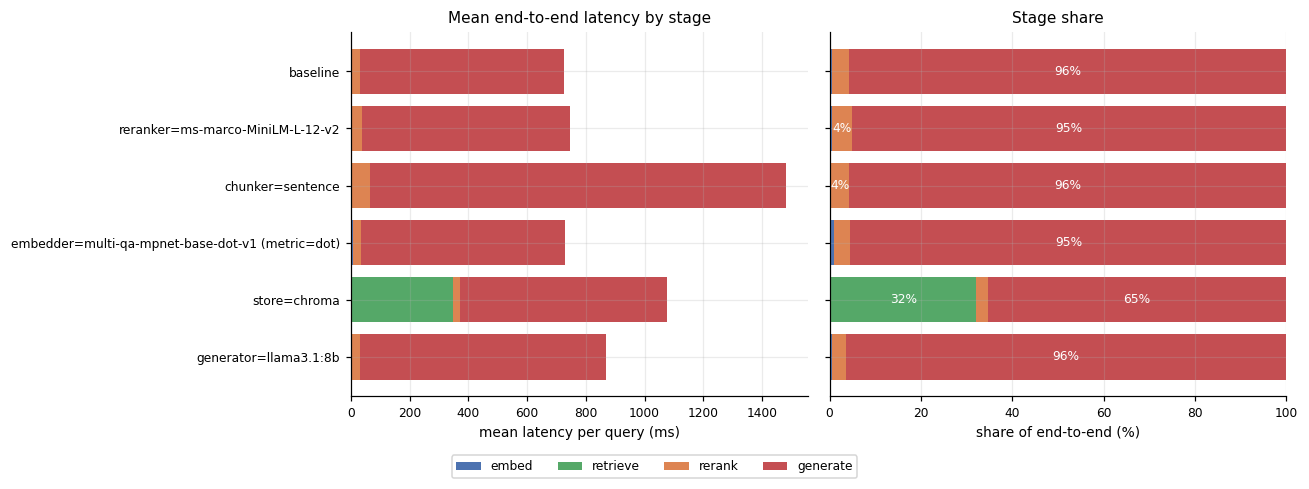

,embed,retrieve,rerank,generate,e2e
arm,,,,,
baseline,3.781,0.460,26.245,695.821,726.308
reranker=ms-marco-MiniLM-L-12-v2,3.753,0.436,32.707,709.694,746.590
chunker=sentence,3.824,0.333,60.432,1417.189,1481.778
embedder=multi-qa-mpnet-base-dot-v1 (metric=dot),6.506,0.490,26.064,694.657,727.716
store=chroma,3.777,342.258,26.548,703.645,1076.228
generator=llama3.1:8b,3.787,0.461,26.143,837.495,867.886


In [29]:
stage_mean = (q.groupby("arm", observed=True)[["lat_" + s for s in STAGES]]
                .mean().loc[ORDER])
stage_mean.columns = STAGES
share = stage_mean.div(stage_mean.sum(axis=1), axis=0) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
left = np.zeros(len(ORDER))
ypos = np.arange(len(ORDER))
for s in STAGES:
    ax1.barh(ypos, stage_mean[s], left=left, color=STAGE_COLOR[s], label=s)
    left += stage_mean[s].to_numpy()
ax1.set_yticks(ypos); ax1.set_yticklabels(ORDER); ax1.invert_yaxis()
ax1.set_xlabel("mean latency per query (ms)")
ax1.set_title("Mean end-to-end latency by stage")
# The bars fill the axes, so the stage key goes under the figure rather than on top of
# the baseline row.
fig.legend(*ax1.get_legend_handles_labels(), ncol=4, fontsize=8,
           loc="lower center", bbox_to_anchor=(0.5, -0.06))

left = np.zeros(len(ORDER))
for s in STAGES:
    ax2.barh(ypos, share[s], left=left, color=STAGE_COLOR[s])
    for y, (x0, w) in enumerate(zip(left, share[s])):
        if w > 4:
            ax2.text(x0 + w / 2, y, "{:.0f}%".format(w), ha="center", va="center",
                     fontsize=8, color="w")
    left += share[s].to_numpy()
ax2.set_yticks(ypos); ax2.set_yticklabels([]); ax2.invert_yaxis()
ax2.set_xlim(0, 100); ax2.set_xlabel("share of end-to-end (%)")
ax2.set_title("Stage share")
fig.tight_layout(); fig.savefig(FIGS / "online_stage_decomposition.png", bbox_inches="tight")
plt.show()

stage_mean.assign(e2e=stage_mean.sum(axis=1)).round(3)

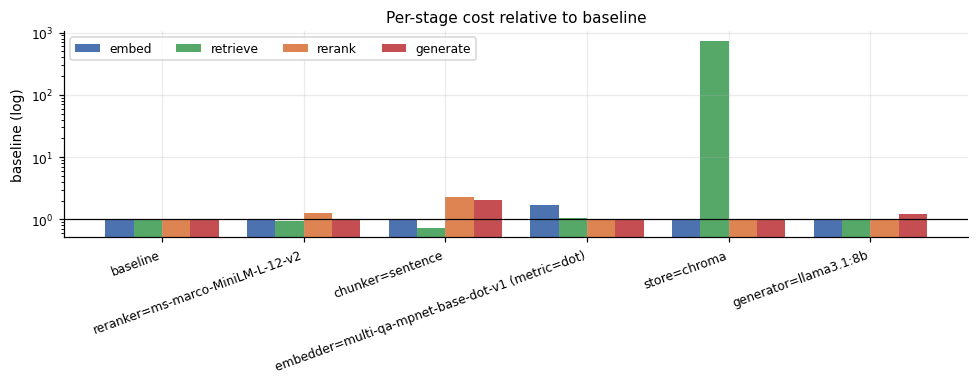

,embed,retrieve,rerank,generate
arm,,,,
baseline,1.000,1.000,1.000,1.000
reranker=ms-marco-MiniLM-L-12-v2,0.993,0.947,1.246,1.020
chunker=sentence,1.012,0.722,2.303,2.037
embedder=multi-qa-mpnet-base-dot-v1 (metric=dot),1.721,1.063,0.993,0.998
store=chroma,0.999,743.319,1.012,1.011
generator=llama3.1:8b,1.002,1.000,0.996,1.204


In [30]:
# Ratio of each arm's stage cost to the baseline's - a one-factor change should move one
# stage and leave the rest alone. Anything else means the arms are not isolated.
ratio = stage_mean.div(stage_mean.loc[BASE], axis=1)
fig, ax = plt.subplots(figsize=(9, 3.6))
w = 0.2
for i, s in enumerate(STAGES):
    ax.bar(np.arange(len(ORDER)) + (i - 1.5) * w, ratio[s], width=w,
           color=STAGE_COLOR[s], label=s)
ax.axhline(1.0, color="k", lw=0.8)
ax.set_yscale("log")
ax.set_xticks(range(len(ORDER)))
ax.set_xticklabels(ORDER, rotation=20, ha="right")
ax.set_ylabel("baseline (log)")
ax.set_title("Per-stage cost relative to baseline")
ax.legend(ncol=4, fontsize=8)
fig.tight_layout(); fig.savefig(FIGS / "online_stage_ratio.png", bbox_inches="tight")
plt.show()
ratio.round(3)

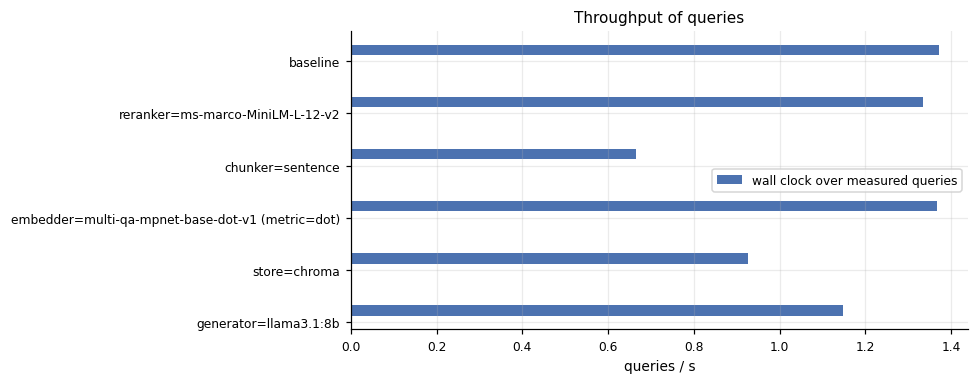

,pipeline_span_s,total_elapsed_s,untimed_in_span_s,post_run_s,qps_stage_sum,qps_wallclock,qps_job,s_per_query
arm,,,,,,,,
baseline,363.922,484.85,1.495,120.928,1.377,1.371,1.029,0.729
reranker=ms-marco-MiniLM-L-12-v2,374.011,401.12,1.463,27.109,1.339,1.334,1.244,0.750
chunker=sentence,750.986,775.84,11.579,24.854,0.675,0.664,0.643,1.505
embedder=multi-qa-mpnet-base-dot-v1 (metric=dot),364.626,387.52,1.496,22.894,1.374,1.369,1.288,0.731
store=chroma,538.596,562.71,1.558,24.114,0.929,0.926,0.887,1.079
generator=llama3.1:8b,434.694,467.36,1.619,32.666,1.152,1.148,1.068,0.871


In [31]:
acct = []
for _, r in runs.iterrows():
    g = q[q.job_id == r.job_id]
    stage_s = g.e2e_ms.sum() / 1000
    acct.append({
        "arm": r.arm,
        "pipeline_span_s": r.span_s,
        "total_elapsed_s": r.total_elapsed_s,
        "untimed_in_span_s": r.span_s - stage_s,
        "post_run_s":        r.total_elapsed_s - r.span_s,
        "qps_stage_sum": r.n / stage_s,
        "qps_wallclock": r.n / r.span_s,
        "qps_job":       r.n / r.total_elapsed_s,
        "s_per_query":   r.span_s / r.n,
    })
acct = pd.DataFrame(acct).set_index("arm").loc[ORDER]

fig, ax = plt.subplots(figsize=(9, 3.6))
ypos = np.arange(len(ORDER))
ax.barh(ypos - 0.22, acct.qps_wallclock, height=0.2, color="#4C72B0",
        label="wall clock over measured queries")
ax.set_yticks(ypos); ax.set_yticklabels(ORDER); ax.invert_yaxis()
ax.set_xlabel("queries / s")
ax.set_title("Throughput of queries")
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIGS / "online_throughput.png", bbox_inches="tight")
plt.show()
acct.round(3)

## Quality, recomputed per query

`run_<job>.json` only stores arm-level means, which cannot carry an interval. The block
below recomputes retrieval quality from the stored `relevant_ranks` and generation
quality from the stored answer text, then **asserts** the recomputation reproduces the
reported aggregates. If an assertion fires, the definitions here and the ones in
`rag_pipeline/metrics.py` have diverged and nothing downstream should be trusted.

In [32]:
def recall_at_k(ranks, k):
    return float(any(r < k for r in ranks))

def precision_at_k(ranks, k):
    return sum(r < k for r in ranks) / k

def rr_at_k(ranks, k):
    hit = [r for r in ranks if r < k]
    return 1.0 / (min(hit) + 1) if hit else 0.0

def ndcg_at_k(ranks, k, ideal_n):
    # Both sides of the rerank comparison are normalised against the ideal ranking of the
    # SHARED candidate pool, matching evaluate.py: normalising the after-list against
    # itself would reward a reranker for discarding relevant chunks.
    dcg  = sum(1 / np.log2(r + 2) for r in ranks if r < k)
    idcg = sum(1 / np.log2(i + 2) for i in range(min(ideal_n, k)))
    return dcg / idcg if idcg else 0.0


K = EVAL_K
pool_n = q.ranks_retrieved.map(lambda r: len(r) if r is not None else 0)

for side in ("retrieved", "reranked"):
    col = "ranks_" + side
    tag = "" if side == "retrieved" else "_rr"
    q["recall" + tag]    = [recall_at_k(r, K) if r is not None else np.nan for r in q[col]]
    q["precision" + tag] = [precision_at_k(r, K) if r is not None else np.nan for r in q[col]]
    q["mrr" + tag]       = [rr_at_k(r, K) if r is not None else np.nan for r in q[col]]
    q["ndcg" + tag]      = [ndcg_at_k(r, K, n) if r is not None else np.nan
                            for r, n in zip(q[col], pool_n)]

# --- generation metrics, same normalisation as rag_pipeline/metrics.py ----------------
_PUNCT = set(string.punctuation)

def normalise_answer(text):
    text = (text or "").lower()
    text = "".join(ch for ch in text if ch not in _PUNCT)
    text = re.sub(r"\b(a|an|the)\b", " ", text)
    return " ".join(text.split())

def answer_accuracy(pred, golds):
    p = normalise_answer(pred)
    if not p:
        return 0.0
    for a in golds:
        a = normalise_answer(a)
        if a and re.search(r"\b" + re.escape(a) + r"\b", p):
            return 1.0
    return 0.0

def token_f1_any(pred, golds):
    pt = normalise_answer(pred).split()
    best = 0.0
    for g in golds:
        gt = normalise_answer(g).split()
        if not pt or not gt:
            best = max(best, float(pt == gt)); continue
        shared = sum((Counter(pt) & Counter(gt)).values())
        if shared:
            pr, rc = shared / len(pt), shared / len(gt)
            best = max(best, 2 * pr * rc / (pr + rc))
    return best

q["answer_accuracy"] = [answer_accuracy(a, g) for a, g in zip(q.answer, q.all_answers)]
q["token_f1"]        = [token_f1_any(a, g) for a, g in zip(q.answer, q.all_answers)]

# --- reconciliation against the reported aggregates ----------------------------------
checks = []
for job in jobs:
    g, s = q[q.job_id == job], metas[job]["stages"]
    for name, mine, theirs in [
        ("recall@k",        g.recall.mean(),          s["retrieval"]["recall_at_k"]),
        ("precision@k",     g.precision.mean(),       s["retrieval"]["precision_at_k"]),
        ("mrr",             g.mrr.mean(),             s["retrieval"]["mrr"]),
        ("ndcg@k",          g.ndcg.mean(),            s["retrieval"]["ndcg_at_k"]),
        ("mrr_after",       g.mrr_rr.mean(),          s["reranking"]["mrr_after"]),
        ("ndcg_after",      g.ndcg_rr.mean(),         s["reranking"]["ndcg_after"]),
        ("recall_after",    g.recall_rr.mean(),       s["reranking"]["recall_after"]),
        # The reranker's own lift, checked against the value the pipeline reports, so the
        # ndcg_rerank_lift column in section 10 is provably the same quantity.
        ("ndcg_delta", g.ndcg_rr.mean() - g.ndcg.mean(), s["reranking"]["ndcg_delta"]),
        ("mrr_delta",  g.mrr_rr.mean() - g.mrr.mean(),   s["reranking"]["mrr_delta"]),
        ("answer_accuracy", g.answer_accuracy.mean(), s["generation"]["avg_answer_accuracy"]),
        ("token_f1",        g.token_f1.mean(),        s["generation"]["avg_token_f1"]),
    ]:
        checks.append({"job_id": job, "metric": name,
                       "recomputed": mine, "reported": theirs,
                       "abs_diff": abs(mine - theirs)})
checks = pd.DataFrame(checks)
worst = checks.abs_diff.max()
assert worst < 1e-9, checks.sort_values("abs_diff", ascending=False).head(10)
print("recomputation matches every reported aggregate; max |diff| = {:.2e}".format(worst))

recomputation matches every reported aggregate; max |diff| = 1.11e-16


In [33]:
# BERTScore and ROUGE-L are only stored as arm-level means (the scorers run in a batch
# pass after the run), so they come from the run json and carry no interval.
QUAL = ["recall","precision", "mrr", "ndcg", "recall_rr", "mrr_rr", "ndcg_rr",
        "answer_accuracy", "token_f1", "context_overflow"]
qual = q.groupby("arm", observed=True)[QUAL].mean().loc[ORDER]

JOB_OF = {arm: job for job, arm in ARMS.items()}
for col, key in [("rouge_l", "avg_rouge_l"), ("bert_score", "avg_bert_score")]:
    qual[col] = [metas[JOB_OF[a]]["stages"]["generation"][key] for a in ORDER]
qual.round(4)

,recall,precision,mrr,ndcg,recall_rr,mrr_rr,ndcg_rr,answer_accuracy,token_f1,context_overflow,rouge_l,bert_score
arm,,,,,,,,,,,,
baseline,0.9539,0.1112,0.7085,0.7257,1.000,0.9915,0.9481,0.7154,0.2105,0.0000,0.2185,0.1334
reranker=ms-marco-MiniLM-L-12-v2,0.9539,0.1112,0.7085,0.7257,1.000,0.9916,0.9483,0.7355,0.2104,0.0000,0.2178,0.1367
chunker=sentence,0.9980,0.1196,0.9541,0.9140,1.000,0.9970,0.9449,0.0882,0.0575,0.9719,0.0636,-0.0400
embedder=multi-qa-mpnet-base-dot-v1 (metric=dot),0.9739,0.1150,0.7913,0.7940,1.000,0.9915,0.9478,0.7134,0.2126,0.0000,0.2180,0.1366
store=chroma,0.9499,0.1102,0.7045,0.7218,0.996,0.9875,0.9442,0.7234,0.2113,0.0000,0.2200,0.1345
generator=llama3.1:8b,0.9539,0.1112,0.7085,0.7257,1.000,0.9915,0.9481,0.8597,0.2899,0.0000,0.3072,0.2042


## Generation internals

Generation owns most of end-to-end, so this is where the latency actually lives.
Time-to-first-token is the queueing/prefill cost; the remainder is decode, which scales
with how many tokens the model chose to emit.

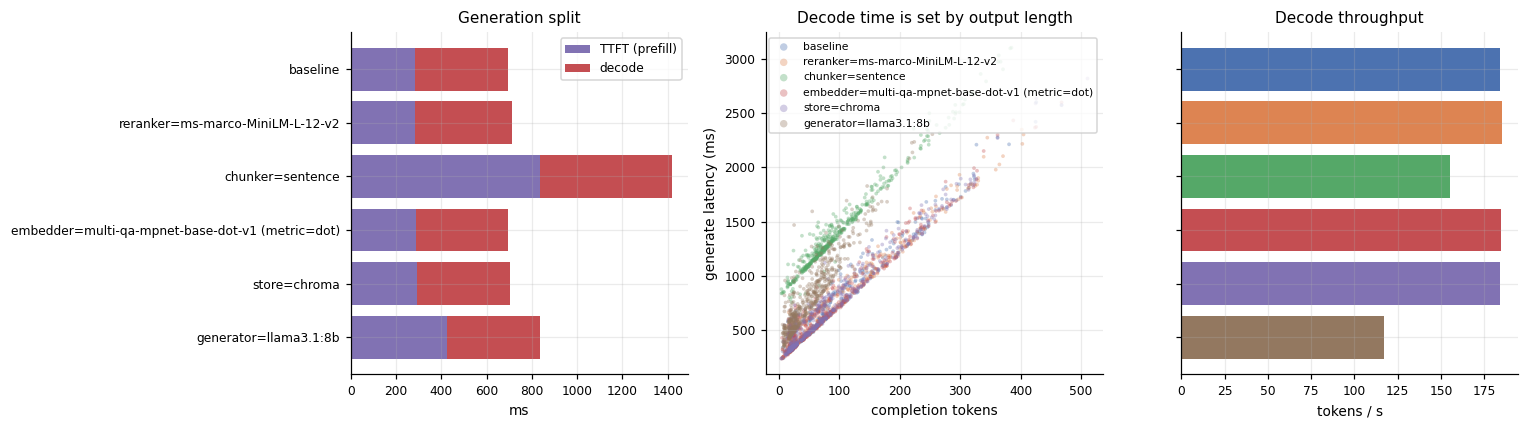

,ttft_ms,decode_ms,generate_ms,prompt_tokens,completion_tokens,tokens_per_sec,ttft_share_pct,overflow_rate,"r(completion_tokens, generate)","r(prompt_tokens, ttft)"
arm,,,,,,,,,,
baseline,284.77,411.05,695.82,1492.08,82.14,184.31,40.93,0.00,0.983,0.011
reranker=ms-marco-MiniLM-L-12-v2,284.62,425.07,709.69,1493.92,85.19,185.16,40.10,0.00,0.983,0.096
chunker=sentence,836.47,580.72,1417.19,8139.87,99.39,155.07,59.02,0.97,0.987,0.476
embedder=multi-qa-mpnet-base-dot-v1 (metric=dot),285.61,409.04,694.66,1488.43,81.95,184.50,41.12,0.00,0.980,-0.043
store=chroma,290.22,413.42,703.65,1492.08,82.28,184.15,41.25,0.00,0.980,0.073
generator=llama3.1:8b,424.19,413.31,837.50,1477.08,53.76,117.23,50.65,0.00,0.927,0.084


In [34]:
gen = q.dropna(subset=["ttft_ms"]).copy()
gen["decode_ms"] = gen.lat_generate - gen.ttft_ms

tbl = gen.groupby("arm", observed=True).agg(
    ttft_ms=("ttft_ms", "mean"),
    decode_ms=("decode_ms", "mean"),
    generate_ms=("lat_generate", "mean"),
    prompt_tokens=("prompt_tokens", "mean"),
    completion_tokens=("completion_tokens", "mean"),
    tokens_per_sec=("tokens_per_sec", "mean"),
).loc[ORDER]
tbl["ttft_share_pct"] = 100 * tbl.ttft_ms / tbl.generate_ms
tbl["overflow_rate"]  = q.groupby("arm", observed=True).context_overflow.mean().loc[ORDER]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
ypos = np.arange(len(ORDER))
axes[0].barh(ypos, tbl.ttft_ms, color="#8172B3", label="TTFT (prefill)")
axes[0].barh(ypos, tbl.decode_ms, left=tbl.ttft_ms, color="#C44E52", label="decode")
axes[0].set_yticks(ypos); axes[0].set_yticklabels(ORDER); axes[0].invert_yaxis()
axes[0].set_xlabel("ms"); axes[0].set_title("Generation split"); axes[0].legend(fontsize=8)

for arm in ORDER:
    g = gen[gen.arm == arm]
    axes[1].scatter(g.completion_tokens, g.lat_generate, s=6, alpha=0.35,
                    color=COLOR[arm], label=arm, edgecolors="none")
axes[1].set_xlabel("completion tokens"); axes[1].set_ylabel("generate latency (ms)")
axes[1].set_title("Decode time is set by output length")
axes[1].legend(fontsize=7, markerscale=2)

axes[2].barh(ypos, tbl.tokens_per_sec, color=[COLOR[a] for a in ORDER])
axes[2].set_yticks(ypos); axes[2].set_yticklabels([]); axes[2].invert_yaxis()
axes[2].set_xlabel("tokens / s"); axes[2].set_title("Decode throughput")
fig.tight_layout(); fig.savefig(FIGS / "online_generation.png", bbox_inches="tight")
plt.show()

corr = gen.groupby("arm", observed=True).apply(
    lambda g: pd.Series({
        "r(completion_tokens, generate)": g.completion_tokens.corr(g.lat_generate),
        "r(prompt_tokens, ttft)":         g.prompt_tokens.corr(g.ttft_ms),
    }), include_groups=False).loc[ORDER]
tbl.round(2).join(corr.round(3))

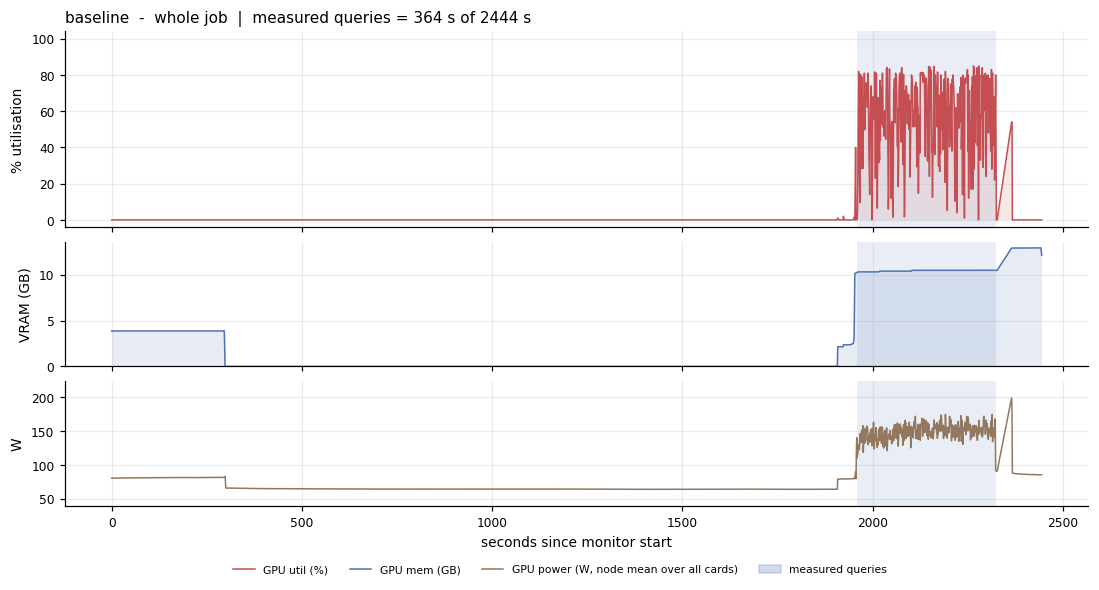

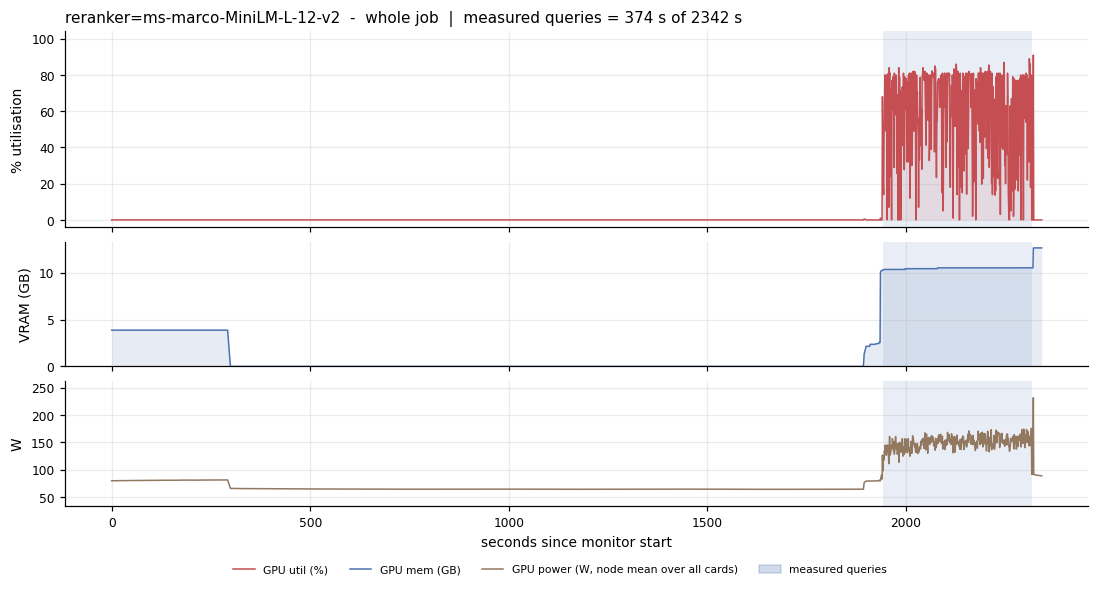

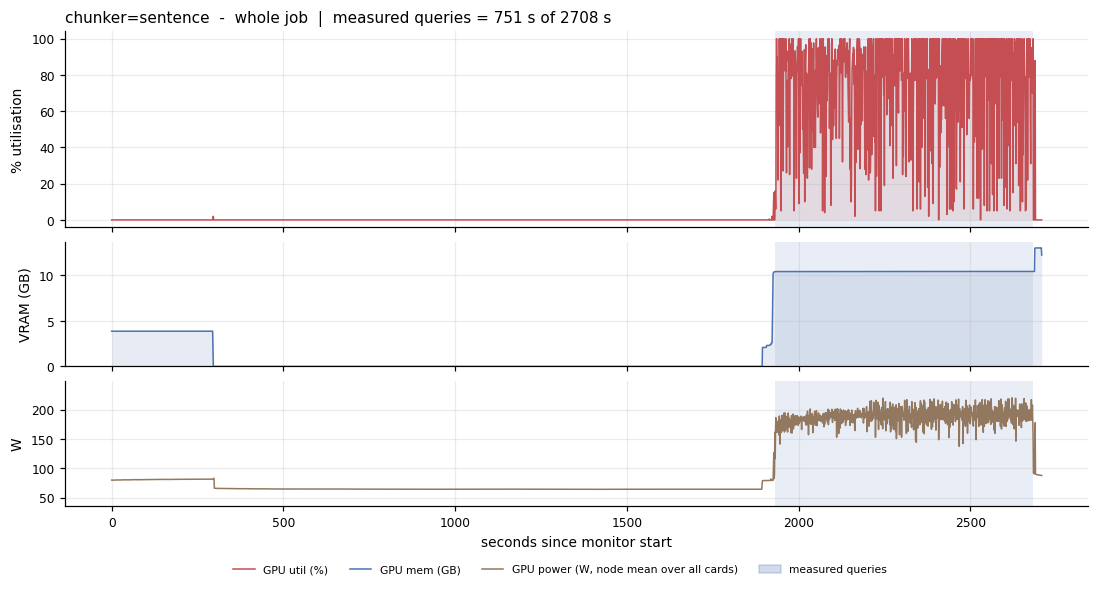

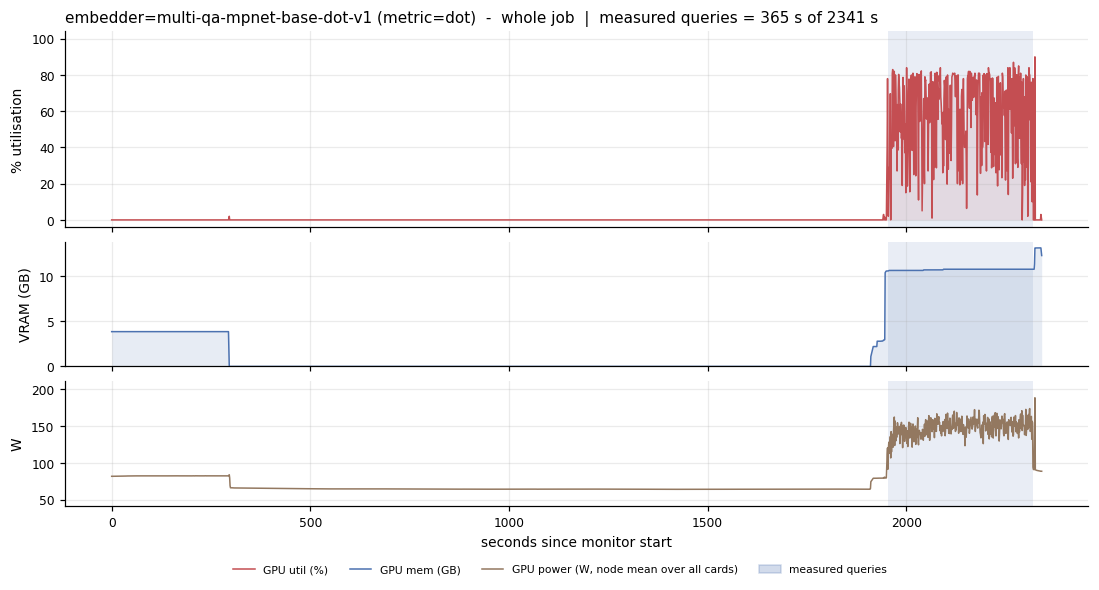

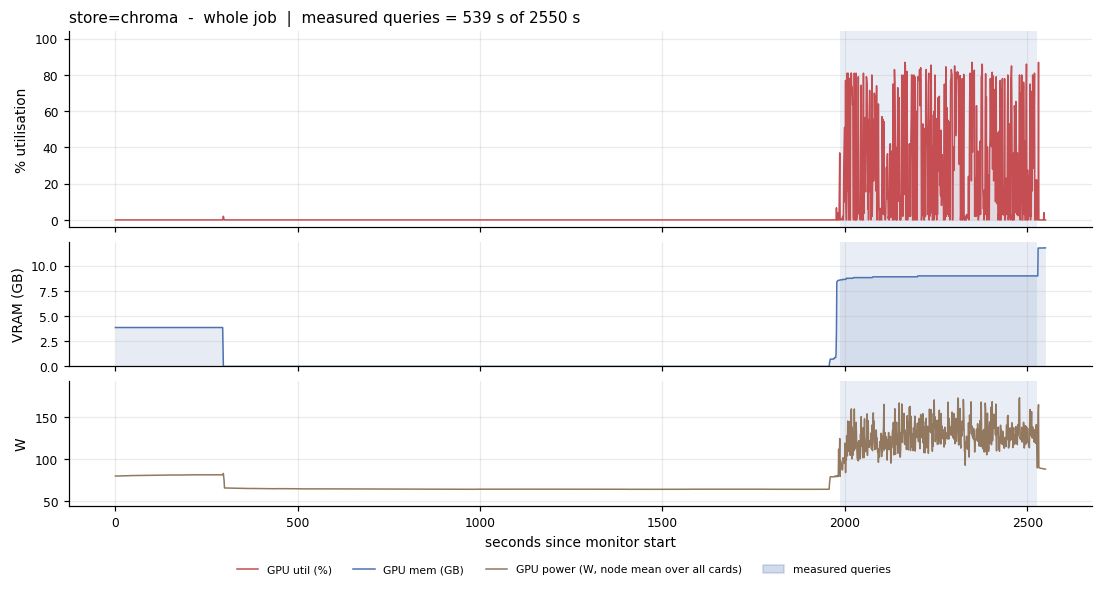

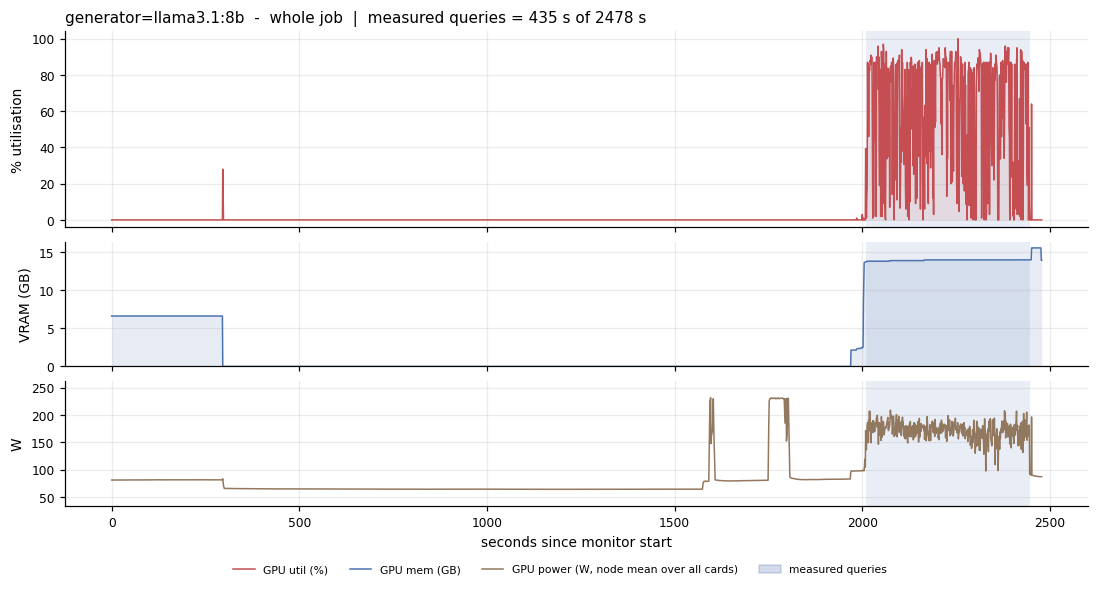

In [37]:
# The trace's own view of the same window, drawn exactly like the offline timelines:
# one metric per panel on a shared time axis, no twin axes. util and VRAM are nvidia-smi
# columns filtered by monitor.sh to $CUDA_VISIBLE_DEVICES, so they are this job's own
# card; power is a DCGM column averaged over every card on the node, which is why it
# does not share a scale with them.
UTIL_COLOR  = "#C44E52"
MEM_COLOR   = "#4C72B0"
POWER_COLOR = "#937860"
QUERY_COLOR = "#4C72B0"   # shading for [pipeline_start, pipeline_end]


def slug(arm):
    # Arm labels carry '=', ':' and '/' (generator=llama3.1:8b), none of which are legal
    # in a Windows filename - the figures are named after the arm, so flatten it here.
    return re.sub(r"[^A-Za-z0-9]+", "_", arm).strip("_").lower()


def per_second(d):
    # monitor.sh stamps whole seconds but does not sample at a fixed rate (~2.5-3 rows/s
    # busy against ~1 idle), so raw rows would draw the busy stretches denser than the
    # idle ones. One mean per wall-clock second restores an evenly spaced series - the
    # same collapse hw_seconds() applies to the numbers.
    out = d.select_dtypes("number").groupby(d.timestamp).mean()
    out.index.name = "timestamp"
    return out.reset_index()


def draw_util(ax, d, t0, marker=False):
    x = (d["timestamp"] - t0).dt.total_seconds()
    ax.fill_between(x, 0, d["gpu_util_pct"], color=UTIL_COLOR, alpha=0.13, lw=0)
    ax.plot(x, d["gpu_util_pct"], color=UTIL_COLOR, lw=1.0,
            marker="o" if marker else None, ms=3, label="GPU util (%)")
    ax.set_ylabel("% utilisation")
    ax.set_ylim(-4, 104)
    return ax.get_legend_handles_labels()


def draw_mem(ax, d, t0, marker=False):
    x = (d["timestamp"] - t0).dt.total_seconds()
    ax.fill_between(x, 0, d["gpu_mem_GB"], color=MEM_COLOR, alpha=0.13, lw=0)
    ax.plot(x, d["gpu_mem_GB"], color=MEM_COLOR, lw=1.0,
            marker="s" if marker else None, ms=3, label="GPU mem (GB)")
    ax.set_ylabel("VRAM (GB)")
    ax.set_ylim(bottom=0)
    ax.margins(y=0.18)
    return ax.get_legend_handles_labels()


def draw_power(ax, d, t0, marker=False):
    x = (d["timestamp"] - t0).dt.total_seconds()
    ax.plot(x, d["power_w"], color=POWER_COLOR, lw=1.0,
            marker="^" if marker else None, ms=3,
            label="GPU power (W, node mean over all cards)")
    ax.set_ylabel("W")
    ax.margins(y=0.18)
    return ax.get_legend_handles_labels()


def draw_metric_stack(axes, d, t0, marker=False):
    # axes = (util, mem, power), top to bottom. Returns pooled legend entries.
    hs, ls_ = [], []
    for a, fn in zip(axes, (draw_util, draw_mem, draw_power)):
        h, l = fn(a, d, t0, marker=marker)
        hs += h; ls_ += l
    return hs, ls_


# --- View A: the whole job, the measured-query span shaded -----------------------
# Setup, model load and warm-up all sit outside that span, and so does the post-run
# scoring pass - nothing in this notebook describes them.
for job in HW:
    d  = per_second(HW[job])
    r  = runs.set_index("job_id").loc[job]
    t0 = d.timestamp.min()

    fig, axs = plt.subplots(
        3, 1, figsize=(12, 5.6), sharex=True,
        gridspec_kw={"height_ratios": [2.2, 1.4, 1.4], "hspace": 0.10})

    hs, ls_ = draw_metric_stack(axs, d, t0)
    for a in axs:
        a.axvspan((r.pipeline_start - t0).total_seconds(),
                  (r.pipeline_end - t0).total_seconds(),
                  color=QUERY_COLOR, alpha=0.12, lw=0)
    job_min = (d.timestamp.max() - t0).total_seconds()
    axs[0].set_title("{}  -  whole job  |  measured queries = {:.0f} s of {:.0f} s"
                     .format(r.arm, r.span_s, job_min), loc="left")
    axs[-1].set_xlabel("seconds since monitor start")
    ph = [Patch(color=QUERY_COLOR, alpha=0.25, label="measured queries")]
    fig.legend(hs + ph, ls_ + [p.get_label() for p in ph], ncol=4, fontsize=7,
               loc="upper center", bbox_to_anchor=(0.5, 0.03), frameon=False)
    fig.savefig(FIGS / ("online_timeline_job_" + slug(r.arm) + ".png"),
                bbox_inches="tight")
    plt.show()

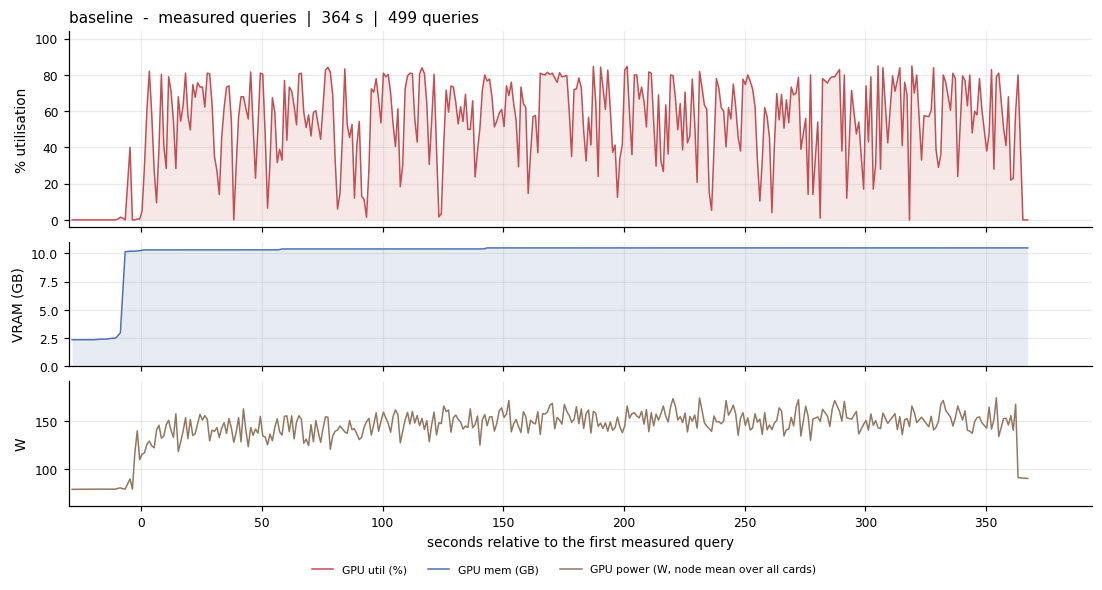

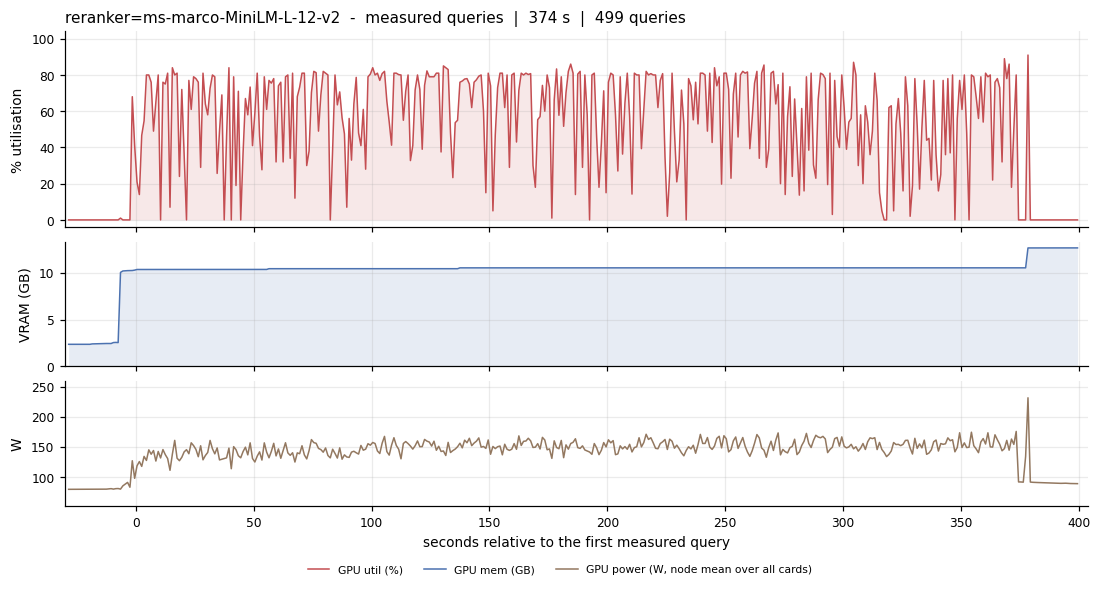

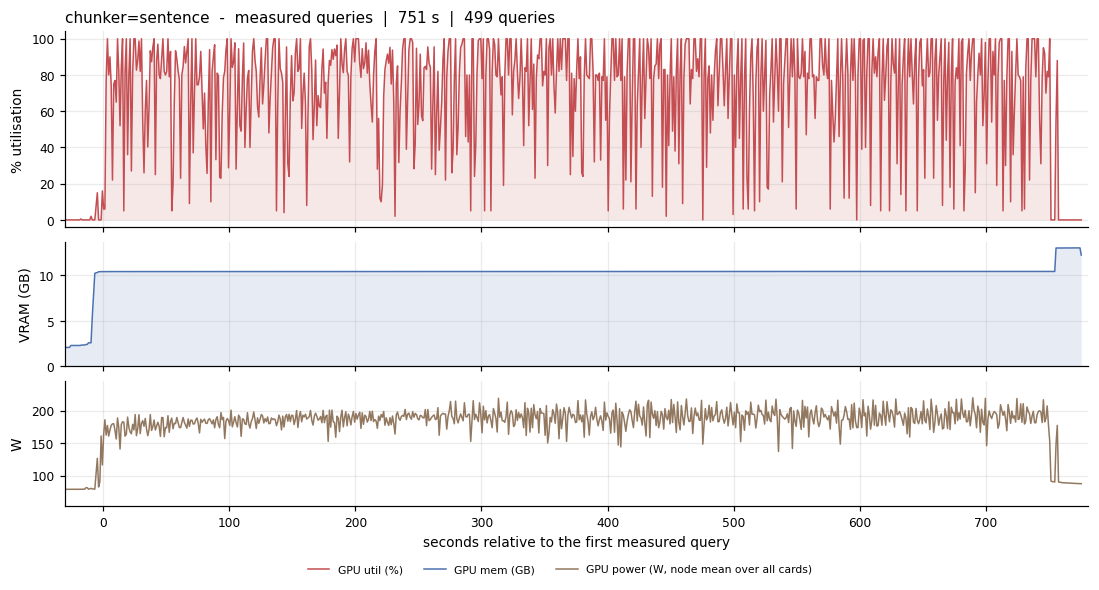

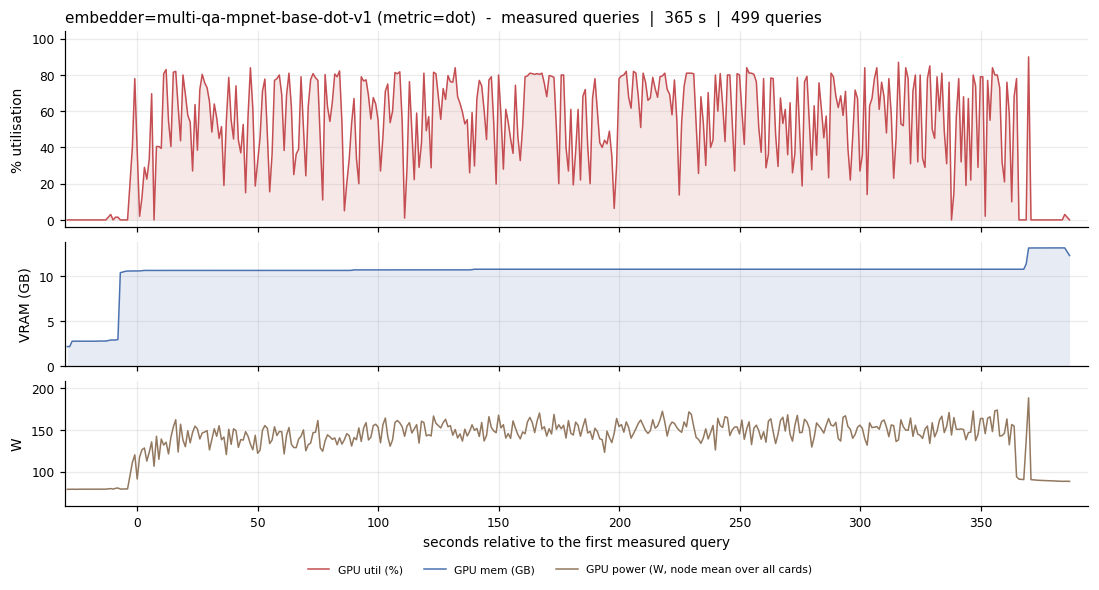

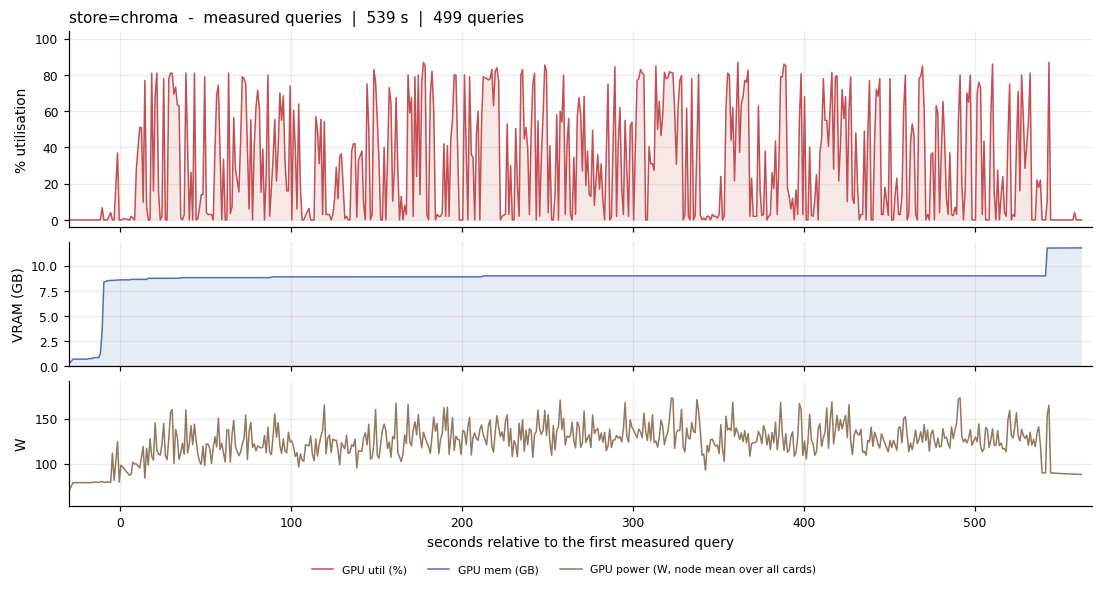

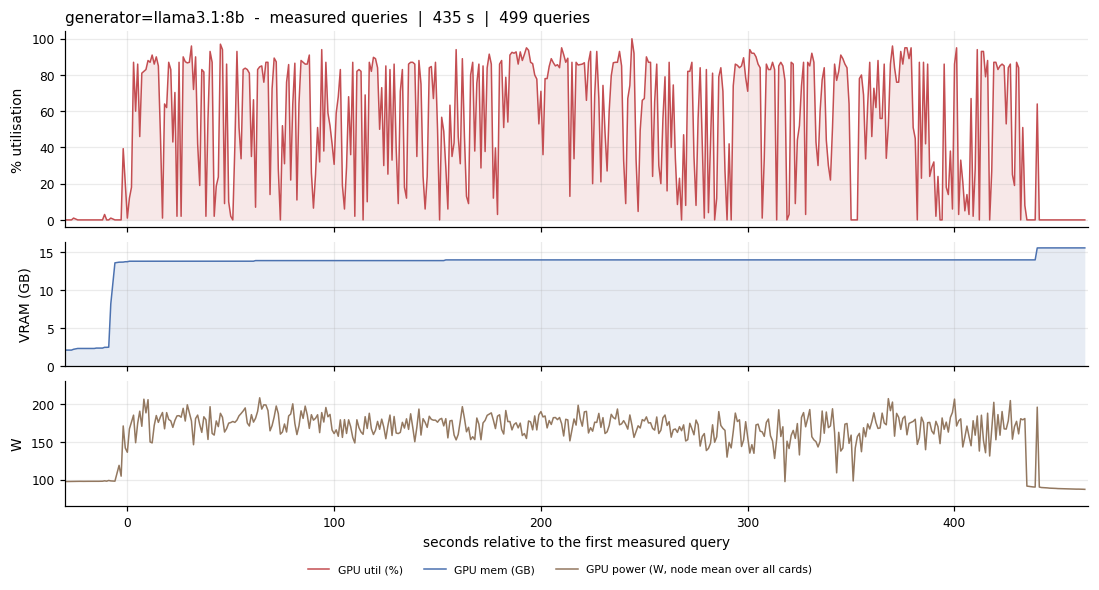

In [36]:
# --- View B: the measured-query window, zoomed ----------------------------------
# The offline notebook puts a per-batch stage ribbon under this view. There is no
# equivalent here: the online traces time each stage per query, not as wall-clock
# spans, so there is nothing to lay on a shared axis - the panels stand alone.
PAD_S = 30   # seconds of context either side of the serving window

for job in HW:
    r  = runs.set_index("job_id").loc[job]
    d  = HW[job]
    lo = r.pipeline_start - pd.Timedelta(seconds=PAD_S)
    hi = r.pipeline_end   + pd.Timedelta(seconds=PAD_S)
    w  = per_second(d[(d.timestamp >= lo) & (d.timestamp <= hi)])
    if w.empty:
        print(ARMS[job], "- no hardware samples in the serving window, skipped")
        continue
    t0 = r.pipeline_start

    fig, axs = plt.subplots(
        3, 1, figsize=(12, 5.6), sharex=True,
        gridspec_kw={"height_ratios": [2.2, 1.4, 1.4], "hspace": 0.10})

    hs, ls_ = draw_metric_stack(axs, w, t0)
    axs[0].set_title("{}  -  measured queries  |  {:.0f} s  |  {} queries"
                     .format(r.arm, r.span_s, r.n), loc="left")
    axs[-1].set_xlabel("seconds relative to the first measured query")
    axs[-1].set_xlim((lo - t0).total_seconds(), (hi - t0).total_seconds())
    fig.legend(hs, ls_, ncol=3, fontsize=7, loc="upper center",
               bbox_to_anchor=(0.5, 0.03), frameon=False)
    fig.savefig(FIGS / ("online_timeline_window_" + slug(r.arm) + ".png"),
                bbox_inches="tight")
    plt.show()